#

In [1]:
import pulp
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
area = [
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 1, 3, 3, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 3, 3, 0, 0, 2, 2, 1, 0, 0, 0, 2, 2, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 0, 0, 1, 1, 3, 3, 1, 1, 2, 2, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 3, 3, 2, 2, 1, 3, 3, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 3, 3, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[0, 0, 0, 3, 3, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
[0, 0, 0, 3, 3, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
[0, 0, 0, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
[0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
[0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
[0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
[1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
[1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
]

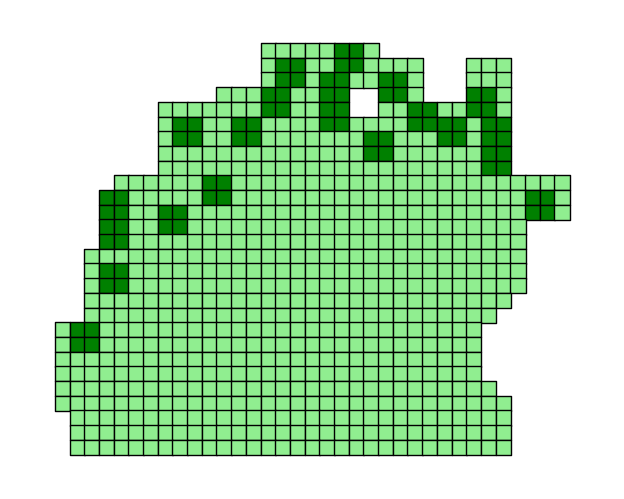

In [3]:
rows, cols = len(area), len(area[0])
G = nx.grid_2d_graph(rows, cols)

grid_nodes = {}
for r in range(rows):
    for c in range(cols):
        if area[r][c] > 0:
            grid_nodes[(r, c)] = area[r][c]
grid = G.subgraph(grid_nodes.keys()).copy()
nx.set_node_attributes(grid, grid_nodes, 'cell_value')

pos = {(x, y): (y, -x) for x, y in G.nodes()}
node_colors = ['lightgreen' if grid.nodes[n]['cell_value'] == 1 else 'green' for n in grid.nodes()]
nx.draw(grid,
        pos,
        node_color=node_colors,
        edgecolors="black",
        node_size=120,
        node_shape='s'
       ) 
#node_labels = {v:grid.nodes[v]["cell_value"] for v in grid.nodes()}
#nx.draw_networkx_labels(grid, pos, labels=node_labels, font_size=10, font_color='black')
plt.gca().set_aspect("equal")
plt.show()

In [4]:
BLOCK_TYPES = ["3x3","4x4","5x5"]
BLOCKS_TO_PLACE = dict(zip(BLOCK_TYPES,[55,5,4]))
OFFSETS = [
([(0,0), (0,1), (0,2), (1,0), (1,1), (1,2), (2,0), (2,1), (2,2)],"3x3",1), 
([(0,0), (0,1), (0,2), (0,3),(1,0), (1,1), (1,2), (1,3),(2,0), (2,1), (2,2), (2,3),(3,0), (3,1), (3,2), (3,3)],"4x4",2), 
([(0,0), (0,1), (0,2), (0,3), (0,4),(1,0), (1,1), (1,2), (1,3), (1,4),(2,0), (2,1), (2,2), (2,3), (2,4),(3,0), (3,1), 
  (3,2), (3,3), (3,4),(4,0), (4,1), (4,2), (4,3), (4,4)],"5x5",3), 

]
COLORS = dict(zip([i for i in range(1,4)],[
    "#1f77b4",  # blue 
    "#393b79",  # dark blue
    "#ff0000" # red
]))

blocks = []
for node in grid.nodes():
    x0, y0 = node
    for offset,name,id in OFFSETS:
        T = [(x0 + dx, y0 + dy) for (dx, dy) in offset]
        if all(grid.has_node(v) for v in T): 
            B=grid.subgraph(T).copy()
            B.graph["type"] = name
            B.graph["color"] = COLORS[id]
            blocks.append(B)
blocks_dict = dict(zip([i for i in range(len(blocks))],blocks))

nodes_with_2 = [n for n, attr in grid.nodes(data=True) if attr.get('cell_value') == 2]
value_2_graph = grid.subgraph(nodes_with_2)
nodes_with_3 = [n for n, attr in grid.nodes(data=True) if attr.get('cell_value') == 3]
value_3_graph = grid.subgraph(nodes_with_3)
components = list(nx.connected_components(value_2_graph))+list(nx.connected_components(value_3_graph))
trees_dict = dict(zip([i for i in range(len(components))],[grid.subgraph(c).copy() for c in components]))
#nx.draw(value_2_graph,pos,node_color="green",edgecolors="black",node_size=120,node_shape='s')

In [5]:
# create problem
prob = pulp.LpProblem("cutting_trees", pulp.LpMinimize)

# x[p] = 1 <=> block p is used
x = pulp.LpVariable.dicts("x",blocks_dict,cat=pulp.LpBinary)
# y[c] = 1 <=> cell c is covered
y = pulp.LpVariable.dicts("y",grid.nodes(),cat=pulp.LpBinary)
# z[t] = 1 <=> tree t is cut
z = pulp.LpVariable.dicts("z",trees_dict.keys(),cat=pulp.LpBinary)

# minimize the number of cut trees
prob+= pulp.lpSum(z)

# place the required number of blocks
for b_type in BLOCK_TYPES:
    prob+= pulp.lpSum(x[p] for p in blocks_dict if blocks_dict[p].graph["type"]==b_type) == BLOCKS_TO_PLACE[b_type]

# no overlap
for v in grid.nodes():
    prob+= pulp.lpSum(x[p] for p in blocks_dict if v in blocks_dict[p].nodes()) == y[v]

# tree cuts
for t in trees_dict:
    tree = trees_dict[t]
    for p in tree.nodes():
        prob+= y[p] <= z[t]

In [6]:
prob.solve()

1

In [7]:
print("cut trees = ",pulp.value(prob.objective))

cut trees =  13.0

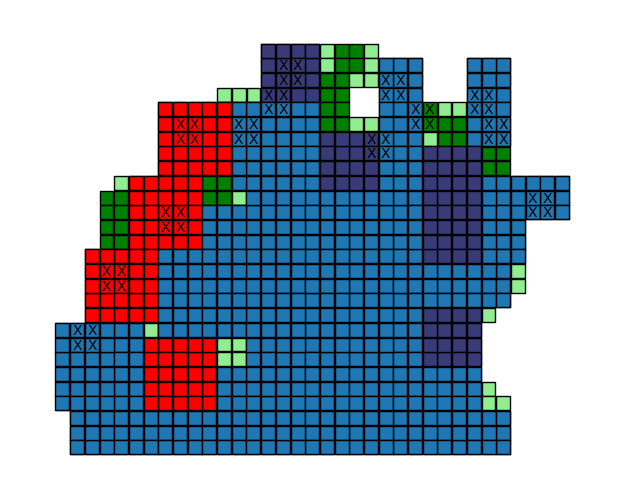

In [8]:
nx.draw(grid,
        pos,
        node_color=node_colors,
        edgecolors="black",
        node_size=100,
        node_shape='s'
       ) 

for p in x:
    if pulp.value(x[p])>0.9:
        B = blocks_dict[p]
        nx.draw(B, pos, 
                node_color=B.graph["color"],
                edgecolors="black",
                node_size=100,
                node_shape='s',
                )
cut_labels = {}        
for t in trees_dict:
    tree = trees_dict[t]
    if pulp.value(z[t])>0.9:
        for p in tree.nodes():
            cut_labels[p]="X"
        
nx.draw_networkx_labels(G, pos, labels=cut_labels, font_size=10, font_color='black')
plt.gca().set_aspect("equal")
plt.show()